In [1]:
pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.2 MB/s eta 0:00:00


In [2]:
import torch
torch.cuda.empty_cache()

import gc
gc.collect()

30

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import matplotlib.pyplot as plt
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)                # Python random
    np.random.seed(seed)             # NumPy
    torch.manual_seed(seed)          # CPU
    torch.cuda.manual_seed(seed)     # GPU
    torch.cuda.manual_seed_all(seed) # multi-GPU

    # For reproducibility (can slow things down)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(28, scale=(0.85, 1.0)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.90, 1.1)),
    transforms.RandomHorizontalFlip(p=0.2),  
    transforms.ToTensor(),
    transforms.Normalize((0.49360984563827515,),(0.2169744223356247)),
])

test_transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize((0.49360984563827515,),(0.2169744223356247)),
])

train_ds = ChestMNIST(split='train', download=True, transform=train_transform)
val_ds = ChestMNIST(split='val', download=True, transform=test_transform)
test_ds = ChestMNIST(split='test', download=True, transform=test_transform)

N = len(train_ds)
labels = train_ds.labels.astype(np.int64)
positive = labels.sum(axis=0)
negative = N - positive
eps = 1e-6
pos_weight = torch.tensor((negative / (positive + eps)) ** 0.5)
pos_weight = torch.clamp(pos_weight, max=15)
pos_weight[3] *= 1.5

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=2,
)

100%|██████████| 82.8M/82.8M [00:56<00:00, 1.47MB/s]


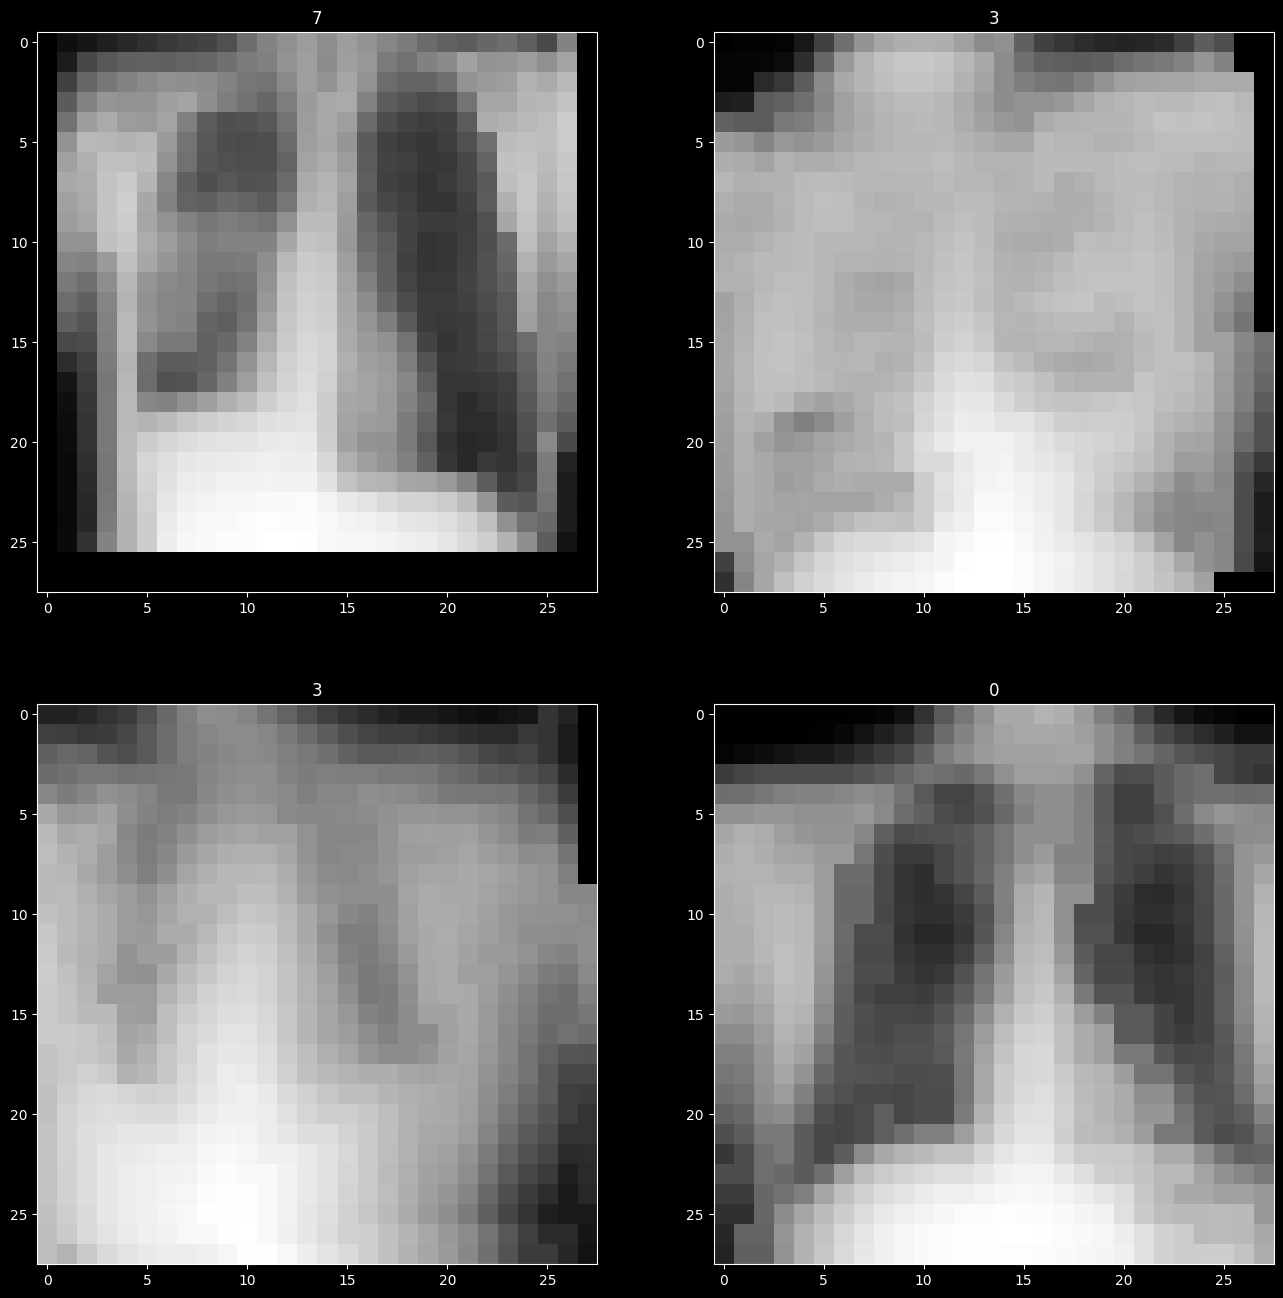

In [4]:
images, labels = next(iter(train_loader))

fig, ax = plt.subplots(2,2,figsize=(16,16))
for i in range(2):
    for j in range(2):
        idx = i*2 + j
        ax[i,j].imshow(images[idx].squeeze(0), cmap='gray')
        ax[i,j].set_title(torch.argmax(labels[idx]).item())


In [5]:
from torchvision.models import resnet18

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model = resnet18(weights=None)

model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()

for param in model.parameters():
    param.requires_grad = True

num_classes = 14
model.fc = nn.Sequential(
   nn.Linear(model.fc.in_features, 256),
   nn.LeakyReLU(),
   nn.Linear(256, 128),
   nn.LeakyReLU(),
   nn.Linear(128, num_classes),
)

#model.fc = nn.Linear(model.fc.in_features, num_classes)

model.to(device)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [6]:
pip install torch_lr_finder

/usr/local/lib/python3.12/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/100 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 5.59E-04


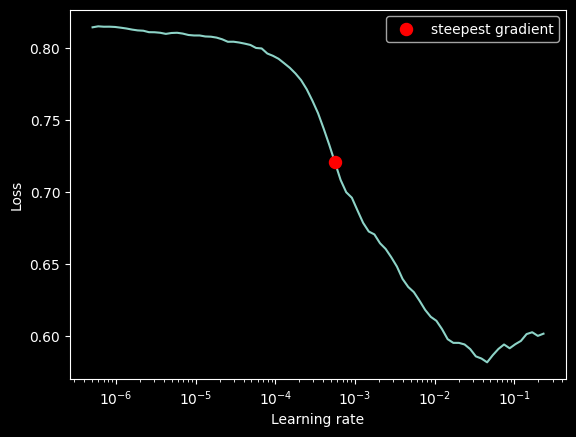

In [7]:
from torch_lr_finder import LRFinder

class FloatTargets(torch.utils.data.Dataset):
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        x, y = self.ds[i]
        y = torch.as_tensor(y, dtype=torch.float32)
        return x, y

train_ds_f = FloatTargets(train_ds)
train_loader_lr = DataLoader(
    train_ds_f,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-7)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

lr_finder = LRFinder(model, optimizer, criterion, device=device)
lr_finder.range_test(train_loader_lr, end_lr=1, num_iter=100)
lr_finder.plot()
lr_finder.reset()

In [ ]:
from sklearn.metrics import roc_auc_score


def compute_auc(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).float()
            output = model(images)
            probs = torch.sigmoid(output)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    auc_per_class = []
    for j in range(all_labels.shape[1]):
        try:
            auc = roc_auc_score(all_labels[:, j], all_preds[:, j])
        except ValueError:
            auc = float('nan')
        auc_per_class.append(auc)

    return np.nanmean(auc_per_class)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Convert to arrays
    y_true = np.vstack(all_labels)
    y_probs = np.vstack(all_probs)

    # Convert probabilities → binary predictions
    y_pred = (y_probs >= threshold).astype(int)

    num_classes = y_true.shape[1]

    # -------------------------
    # Accuracy per class
    # -------------------------
    acc_per_class = []
    for i in range(num_classes):
        acc = accuracy_score(y_true[:, i], y_pred[:, i])
        acc_per_class.append(acc)

    avg_acc = np.mean(acc_per_class)

    # -------------------------
    # Precision / Recall / F1
    # -------------------------
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

    # -------------------------
    # AUC (per class + avg)
    # -------------------------
    auc_per_class = []
    for i in range(num_classes):
        try:
            auc = roc_auc_score(y_true[:, i], y_probs[:, i])
        except:
            auc = np.nan
        auc_per_class.append(auc)

    avg_auc = np.nanmean(auc_per_class)

    # -------------------------
    # Print results
    # -------------------------
    print("\n📊 Accuracy per class:")
    for i, acc in enumerate(acc_per_class):
        print(f"Class {i}: {acc:.4f}")
    print(f"Average Accuracy: {avg_acc:.4f}")

    print("\n📊 Precision / Recall / F1 (micro):")
    print(f"Precision: {precision_micro:.4f}")
    print(f"Recall:    {recall_micro:.4f}")
    print(f"F1 Score:  {f1_micro:.4f}")

    print("\n📊 AUC per class:")
    for i, auc in enumerate(auc_per_class):
        print(f"Class {i}: {auc:.4f}")
    print(f"Average AUC: {avg_auc:.4f}")

    return {
        "acc_per_class": acc_per_class,
        "avg_acc": avg_acc,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "auc_per_class": auc_per_class,
        "avg_auc": avg_auc,
    }

In [10]:
from torch.optim.lr_scheduler import OneCycleLR

num_epochs = 50
best_val_auc = 0.0

pos_weight = pos_weight.to(device)

loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(params=model.parameters(), lr=5e-4, weight_decay=3e-4)
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,          # 🔥 usually 2x your base LR (you used 5e-4)
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
)

# Lists to store metrics per epoch
epoch_losses = []

for epoch in range(num_epochs):
    model.train()
    current_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()

        output = model(images)
        loss = loss_function(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        current_loss += loss.item()

        scheduler.step()

    val_auc = compute_auc(model, val_loader)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "best_model.pth")

    epoch_loss = current_loss / len(train_loader)
    epoch_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val AUC: {val_auc:.4f}")

Epoch [1/50] | Loss: 0.5352 | Val AUC: 0.6836
Epoch [2/50] | Loss: 0.4792 | Val AUC: 0.7022
Epoch [3/50] | Loss: 0.4719 | Val AUC: 0.7226
Epoch [4/50] | Loss: 0.4650 | Val AUC: 0.7377
Epoch [5/50] | Loss: 0.4604 | Val AUC: 0.7459
Epoch [6/50] | Loss: 0.4572 | Val AUC: 0.7509
Epoch [7/50] | Loss: 0.4544 | Val AUC: 0.7547
Epoch [8/50] | Loss: 0.4522 | Val AUC: 0.7616
Epoch [9/50] | Loss: 0.4492 | Val AUC: 0.7649
Epoch [10/50] | Loss: 0.4482 | Val AUC: 0.7630
Epoch [11/50] | Loss: 0.4469 | Val AUC: 0.7644
Epoch [12/50] | Loss: 0.4450 | Val AUC: 0.7722
Epoch [13/50] | Loss: 0.4428 | Val AUC: 0.7689
Epoch [14/50] | Loss: 0.4416 | Val AUC: 0.7765
Epoch [15/50] | Loss: 0.4390 | Val AUC: 0.7713
Epoch [16/50] | Loss: 0.4375 | Val AUC: 0.7738
Epoch [17/50] | Loss: 0.4353 | Val AUC: 0.7662
Epoch [18/50] | Loss: 0.4330 | Val AUC: 0.7673
Epoch [19/50] | Loss: 0.4325 | Val AUC: 0.7730
Epoch [20/50] | Loss: 0.4298 | Val AUC: 0.7828
Epoch [21/50] | Loss: 0.4282 | Val AUC: 0.7737
Epoch [22/50] | Loss: 

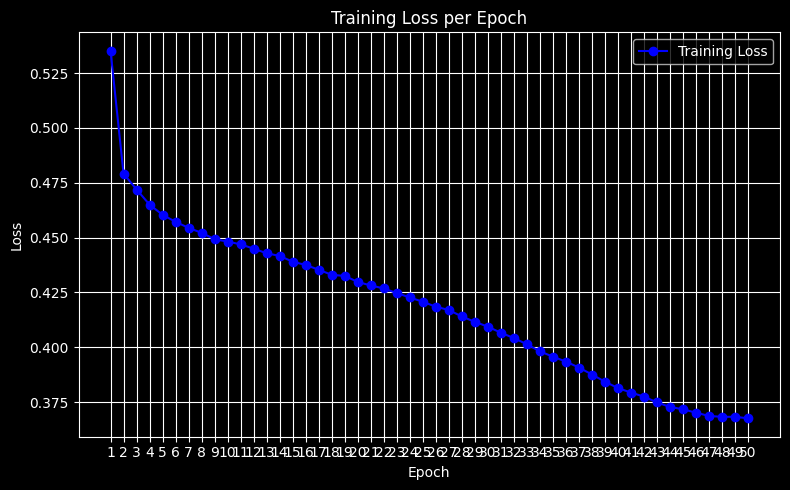

In [11]:
import matplotlib.pyplot as plt

epochs = range(1, len(epoch_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, epoch_losses, marker='o', color='blue', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(epochs)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
model.load_state_dict(torch.load("best_model.pth"))
evaluate_model(model, test_loader, device, threshold=0.5)


📊 Accuracy per class:
Class 0: 0.8420
Class 1: 0.9430
Class 2: 0.8478
Class 3: 0.7472
Class 4: 0.9251
Class 5: 0.9306
Class 6: 0.9884
Class 7: 0.9212
Class 8: 0.9293
Class 9: 0.9584
Class 10: 0.9514
Class 11: 0.9810
Class 12: 0.9498
Class 13: 0.9956
Average Accuracy: 0.9222

📊 Precision / Recall / F1 (micro):
Precision: 0.2985
Recall:    0.3554
F1 Score:  0.3245

📊 AUC per class:
Class 0: 0.7822
Class 1: 0.8881
Class 2: 0.8501
Class 3: 0.6856
Class 4: 0.7665
Class 5: 0.6421
Class 6: 0.7098
Class 7: 0.8254
Class 8: 0.7878
Class 9: 0.8675
Class 10: 0.8099
Class 11: 0.7605
Class 12: 0.7354
Class 13: 0.8898
Average AUC: 0.7858


{'acc_per_class': [0.8420184549547541,
  0.943030357063255,
  0.8478134890563009,
  0.7472473588017653,
  0.9250657513484598,
  0.9305933223376276,
  0.9884099317969064,
  0.9211875362189631,
  0.9293451611465252,
  0.9584094860250524,
  0.9514108679177997,
  0.981010119021085,
  0.9497615120581286,
  0.9956314358311417],
 'avg_acc': np.float64(0.9222096273984117),
 'precision_micro': 0.2985196113343847,
 'recall_micro': 0.35542095699576015,
 'f1_micro': 0.32449470511792516,
 'auc_per_class': [np.float64(0.7822127290814689),
  np.float64(0.8881289256619456),
  np.float64(0.8500563676639697),
  np.float64(0.6856189702211803),
  np.float64(0.7664670014793084),
  np.float64(0.6420637701782622),
  np.float64(0.7098277315164997),
  np.float64(0.8254155463590519),
  np.float64(0.7877978246183974),
  np.float64(0.8674999945020265),
  np.float64(0.8099077488261825),
  np.float64(0.7604944464762265),
  np.float64(0.735361459543145),
  np.float64(0.8897771426019383)],
 'avg_auc': np.float64(0.78

In [ ]:
current_best_test_auc = 0.789377262684418
current_best_test_acc = 0.8579770873267062

In [14]:
import torch
from torch.utils.data import DataLoader

transforms = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor(),
])

ds = ChestMNIST(split='train', download=True, transform=transforms)
loader = DataLoader(ds, batch_size=256, shuffle=False)

mean = 0.0
std = 0.0
total_pixels = 0

for images, _ in loader:
    images = images.view(images.size(0), -1)  # flatten

    mean += images.mean(1).sum()
    std += images.std(1).sum()
    total_pixels += images.size(0)

mean /= total_pixels
std /= total_pixels

print("Mean:", mean.item())
print("Std:", std.item())

Mean: 0.49360984563827515
Std: 0.2169744223356247
